# 19. KV Cache 深入 —— 显存账本 · 增量等价 · 前缀复用 · PagedAttention

自回归生成是**逐 token** 的：第 $t$ 步预测 $t{+}1$，每一步都要注意力。朴素实现每步重新计算前面所有
位置的 $K,V$——浪费 $O(T^2)$ 的计算。**KV Cache** 把已算好的 $K,V$ 存起来，每一步只算新 query。

本讲三件事：
1. 手搓**增量解码 vs 全量重算**：输出逐 token 完全一致，计算量却差 $O(T)$ 倍（FLOPs 计数验证）
2. **KV 显存账本**：MiniMind 真实参数（GQA 4 KV 头）下，KV 缓存要占多少显存（公式 + 曲线）
3. **共享前缀复用**：多个请求共用系统提示时缓存怎么省；vLLM 的 PagedAttention 为什么能省更多


## 1. 公式与账本

**每层 KV 显存**（$N_l$ 层、$N_{kv}$ 个 KV 头、$d_{head}$ 头维、序列长 $T$、字节/元素 $b$）：

$$\mathrm{KV\ bytes}=2\,(K\text{和}V)\times N_l\times N_{kv}\times d_{head}\times T\times b$$

**MiniMind 代入**（GQA：$N_{kv}=4$，$d_{head}=96$，$N_l=8$，fp16 $b=2$）：

$$\text{每 token} = 2\times8\times4\times96\times2=12{,}288\,\text{B}\approx12\,\text{KB/token}$$
$$T=32768 \Rightarrow 12\,\text{KB}\times32768 = 384\,\text{MB / 请求}$$

**计算量对比**（每步）：全量重算 $O(T_{kv}^2)$，增量解码 $O(T_{kv})$（只算新 query 与缓存的点积）。

**GQA 的价值**：MHA（8 头）KV 是 GQA（4 头）的 2 倍——显存省一半（第 8 讲讲原理，本讲算账）。


In [1]:
import numpy as np
import math

# ---- 简化单层注意力：prefill（全量）与 decode（增量，带 KV cache） ----
rng = np.random.default_rng(0)
d, T0, V = 8, 6, 10                       # 特征 8 维，初始序列 6，词表 10
Wq = rng.standard_normal((d, d)) * 0.1; Wk = rng.standard_normal((d, d)) * 0.1
Wv = rng.standard_normal((d, d)) * 0.1; Wo = rng.standard_normal((d, d)) * 0.1

def softmax_rows(x):
    x = x - np.max(x, -1, keepdims=True); e = np.exp(x)
    return e / e.sum(-1, keepdims=True)

def causal_mask(nq, nkv):
    """因果掩码：query 行 i 掩掉 key 列 j>i（True=掩）。prefill 时 nq=nkv（上三角）；
    decode 增量时 nq=1 且 query 绝对位置 = nkv-1，因此 j>nkv-1 为空 -> 全 False（全部可见）。"""
    i = np.arange(nq)[:, None] + (nkv - nq)     # query 的绝对位置
    j = np.arange(nkv)[None, :]
    return j > i

def attn_scores(q, K):
    """q: [nq,d], K: [nkv,d] -> scores [nq,nkv]（带因果掩码与缩放）"""
    nq, nkv = q.shape[0], K.shape[0]
    s = q @ K.T / math.sqrt(d)
    s = np.where(causal_mask(nq, nkv), -np.inf, s)
    return s

def attention_pass(x, cache=None):
    """一层注意力前向。cache=(K,V) 传入时做增量 decode，否则 prefill 全量。
    返回 (out, K, V)：K,V 为该层缓存（下一次 decode 用）。"""
    if cache is None:                        # prefill：一次处理整段 [T,d]
        Q = x @ Wq; K = x @ Wk; V = x @ Wv
        scores = attn_scores(Q, K)
        out = softmax_rows(scores) @ V
        return out @ Wo, K, V
    Kp, Vp = cache                            # decode：先把自己的 K/V 追加进缓存（query 要能 attend 自己）
    K = np.concatenate([Kp, x @ Wk], 0)
    V = np.concatenate([Vp, x @ Wv], 0)
    q = x @ Wq                                # x: [1,d]
    scores = attn_scores(q, K)                # 用含自己的完整 K/V（因果掩码下新行全可见）
    out = softmax_rows(scores) @ V
    return out @ Wo, K, V

def flops_qk(Tq, Tkv):
    """QK^T 的乘加次数（教学简化：只数乘加）。"""
    return Tq * Tkv * d

# ---- 模拟"生成"：贪心选 argmax ----
head = rng.standard_normal((d, V))            # 简化 lm_head [d, V]
def next_logits(h):
    return h @ head

# 初始前缀（6 个 token 的嵌入）——嵌入用固定查找表（确定性，不依赖 rng 调用顺序）
emb_table = rng.standard_normal((V, d)) * 0.5      # [V, d] 词表嵌入表
def embed(ids):
    return emb_table[ids]

ids0 = np.array([0, 3, 5, 2, 7, 1])
M = 8                                        # 再生成 8 个 token

def generate_full(ids, M):
    """无缓存：每步对完整序列重算注意力（每一步 O(T^2)）。"""
    ids = list(ids); flops = 0
    for _ in range(M):
        x = embed(np.array(ids))
        out, K, V = attention_pass(x)
        logits = next_logits(out[-1])
        nxt = int(np.argmax(logits)); flops += flops_qk(len(ids), len(ids))
        ids.append(nxt)
    return ids, flops

def generate_cached(ids, M):
    """带缓存：prefill 一次，之后每步增量（O(T)）。"""
    ids = list(ids)
    x = embed(np.array(ids))
    out, K, V = attention_pass(x)            # prefill
    flops = flops_qk(len(ids), len(ids))
    for _ in range(M):
        logits = next_logits(out[-1])
        nxt = int(np.argmax(logits))
        ids.append(nxt)
        out, K, V = attention_pass(embed(np.array([nxt])), (K, V))   # 增量 decode
        flops += flops_qk(1, len(ids))         # 新 query × 含自己的全部 K/V
    return ids, flops

ids_full, f_full = generate_full(ids0, M)
ids_cache, f_cache = generate_cached(ids0, M)
print('无缓存生成:', ids_full)
print('带缓存生成:', ids_cache)
assert ids_full == ids_cache, '增量解码与全量重算输出不一致！'
print('两种方式生成的 token 序列完全一致  ->  PASS（KV cache 只是省计算，不改结果）')
print(f'QK^T 乘加次数：全量重算 {f_full:,} vs KV cache {f_cache:,}（省 {f_full / max(f_cache, 1):.1f} 倍）')


无缓存生成: [np.int64(0), np.int64(3), np.int64(5), np.int64(2), np.int64(7), np.int64(1), 8, 7, 7, 5, 5, 5, 5, 5]
带缓存生成: [np.int64(0), np.int64(3), np.int64(5), np.int64(2), np.int64(7), np.int64(1), 8, 7, 7, 5, 5, 5, 5, 5]
两种方式生成的 token 序列完全一致  ->  PASS（KV cache 只是省计算，不改结果）
QK^T 乘加次数：全量重算 6,112 vs KV cache 960（省 6.4 倍）


In [2]:
# ---- KV 显存账本（MiniMind 真实参数） ----
def kv_bytes_per_token(n_layers, n_kv_heads, head_dim, bytes_per_elem=2):
    return 2 * n_layers * n_kv_heads * head_dim * bytes_per_elem

mb = kv_bytes_per_token(8, 4, 96, 2)            # fp16
ma = kv_bytes_per_token(8, 8, 96, 2)            # MHA 对照（8 头）
print(f'GQA(4 KV 头): {mb/1024:.1f} KB/token | MHA(8 头): {ma/1024:.1f} KB/token（GQA 省一半）')
for T in [1024, 4096, 8192, 16384, 32768]:
    print(f'  T={T:6d}: GQA {mb*T/2**20:6.1f} MB | MHA {ma*T/2**20:6.1f} MB | 并发 8 请求 GQA {8*mb*T/2**20:7.1f} MB')
assert ma == 2 * mb
print('MHA KV = 2 × GQA KV  ->  PASS')


GQA(4 KV 头): 12.0 KB/token | MHA(8 头): 24.0 KB/token（GQA 省一半）
  T=  1024: GQA   12.0 MB | MHA   24.0 MB | 并发 8 请求 GQA    96.0 MB
  T=  4096: GQA   48.0 MB | MHA   96.0 MB | 并发 8 请求 GQA   384.0 MB
  T=  8192: GQA   96.0 MB | MHA  192.0 MB | 并发 8 请求 GQA   768.0 MB
  T= 16384: GQA  192.0 MB | MHA  384.0 MB | 并发 8 请求 GQA  1536.0 MB
  T= 32768: GQA  384.0 MB | MHA  768.0 MB | 并发 8 请求 GQA  3072.0 MB
MHA KV = 2 × GQA KV  ->  PASS


### KV 显存曲线

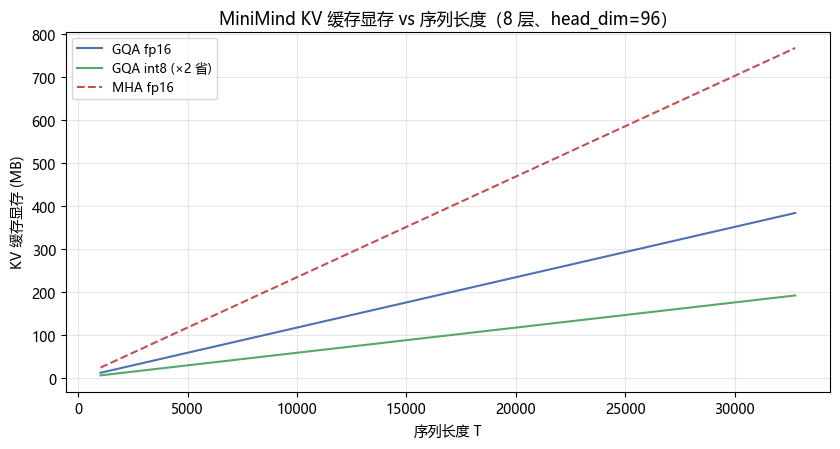

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

Ts = np.arange(1024, 32769, 1024)
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(Ts, kv_bytes_per_token(8, 4, 96, 2) * Ts / 2**20, label='GQA fp16', color='#4C72B0')
ax.plot(Ts, kv_bytes_per_token(8, 4, 96, 1) * Ts / 2**20, label='GQA int8 (×2 省)', color='#55A868')
ax.plot(Ts, kv_bytes_per_token(8, 8, 96, 2) * Ts / 2**20, label='MHA fp16', color='#C44E52', ls='--')
ax.set_xlabel('序列长度 T'); ax.set_ylabel('KV 缓存显存 (MB)')
ax.set_title('MiniMind KV 缓存显存 vs 序列长度（8 层、head_dim=96）', fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [4]:
# ---- 共享前缀复用：两个请求共用系统提示 ----
# 请求 1: 前缀 8 token + 提问 2 token；请求 2: 同前缀 + 另一提问 2 token
P, S1, S2 = 8, 2, 2

def total_flops(P, uniqs, T_gen):
    """统计 prefill + decode 的 QK^T 乘加（数乘加，d=8）。
    naive：每个请求独立完整 prefill（(P+u)²，含重复的前缀部分）；
    opt  ：前缀只 prefill 一次（P×P），每个请求只给独有段 u 个 query 算（u×(P+u)）。"""
    naive = sum(flops_qk(P + u, P + u) + T_gen * flops_qk(1, P + u) for u in uniqs)
    opt = (flops_qk(P, P)
           + sum(flops_qk(u, P + u) + T_gen * flops_qk(1, P + u) for u in uniqs))
    return naive, opt

naive, opt = total_flops(P, [S1, S2], 4)
print(f'共享前缀（前缀 {P} token，2 个请求各 {S1}/{S2} token，各生成 4 token）：')
print(f'  朴素（每个请求独立 prefill 全序列）: {naive:,} 次乘加')
print(f'  前缀缓存复用                     : {opt:,} 次乘加（省 {naive/opt:.1f} 倍）')
assert opt < naive
print('共享前缀缓存复用显著省计算  ->  PASS')


共享前缀（前缀 8 token，2 个请求各 2/2 token，各生成 4 token）：
  朴素（每个请求独立 prefill 全序列）: 2,240 次乘加
  前缀缓存复用                     : 1,472 次乘加（省 1.5 倍）
共享前缀缓存复用显著省计算  ->  PASS


## 2. 生产：PagedAttention 与 Continuous Batching

**vLLM 的核心观察**：传统 KV 缓存按"最大长度"预分配连续内存——请求提前结束就浪费、碎片化严重。

**PagedAttention**：把 KV 缓存切成固定大小**页（block）**，用**块表（block table）**索引——像操作系统分页。
请求只占实际用到的页；多个请求共享前缀时**同一块只存一份**（Copy-on-Write 共享）。

**Continuous Batching**：不再等一个请求生成完，而是把多个请求的 token **混在一个 batch**里推进
（哪个请求有空闲位置就插进去）——GPU 利用率从 ~20% 提到 80%+。

这两个机制叠加 = vLLM/张量并行推理的高吞吐来源。KV cache 显存公式里加一个"并发 × 平均长度"即可估算集群容量。


## 总结

- **KV Cache = 用显存换计算**：增量解码与全量重算**输出逐 token 一致**（本讲 PASS），乘加次数省 $O(T)$ 倍。
- **显存账**：MiniMind GQA（4 KV 头）≈ 12 KB/token，T=32k 时 384 MB/请求；MHA 翻倍；int8 再省一半。
- **前缀复用**：多个请求共享系统提示时，缓存把 prefill 计算按"前缀一次 + 独有段"拆分（本讲 PASS）。
- 生产（vLLM）：**PagedAttention**（分页块表 + 共享）+ **Continuous Batching**（多请求混批）把显存碎片和 GPU 空闲都吃掉。
- 与第 9 讲衔接：`model_minimind.py` 的 `Attention` 里 `k_cache/v_cache` 就是这套机制的实现；本讲算的是它的"经济账"。
